In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

In [2]:
raw_data = pd.read_csv("../raw_data/POLG_TEV_Huber_2025/POLG_TEV_Huber_2025.csv")
#raw_data_no_ins = raw_data.loc[[i for i in raw_data.index if '*' not in str(i)]]

In [3]:
raw_data

,TEVp,TEVs,n_mut_TEVp,n_mut_TEVs,source_TEVp,source_TEVs,N1,N2,N3,N4,...,F4,F5,sum,min,t1,t2,t3,t4,t5,AUC
0,*235L,DNLIFQS,1,2,PacBio,PacBio,158,175,140,167,...,21,39,856,146,0.0000,0.0057,0.0411,0.1117,0.2074,0.0655
1,*235L,DNLYFQS,1,1,PacBio,PacBio,171,177,200,142,...,16,55,929,158,0.0058,0.0112,0.0244,0.1013,0.2558,0.0669
2,*235L,EALYFQS,1,1,PacBio,PacBio,43,46,53,34,...,13,18,271,43,0.0000,0.0213,0.1311,0.2766,0.2466,0.1381
3,*235L,ECLYFQS,1,1,PacBio,PacBio,370,325,288,359,...,58,84,1804,312,0.0000,0.0091,0.0769,0.1391,0.2228,0.0841
4,*235L,EDLYSQS,1,2,PacBio,PacBio,217,263,214,196,...,36,49,1197,218,0.0046,0.0223,0.0573,0.1552,0.1952,0.0837
5,*235L,EELYFQS,1,1,PacBio,PacBio,334,375,340,303,...,60,108,1815,334,0.0000,0.0079,0.0811,0.1653,0.2919,0.1001
6,*235L,EGLYFQS,1,1,PacBio,PacBio,111,128,95,94,...,25,35,602,101,0.0089,0.0000,0.0594,0.2101,0.2465,0.0993
7,*235L,EHLYFQS,1,1,PacBio,PacBio,44,51,29,28,...,8,12,203,35,0.0000,0.0000,0.2162,0.2222,0.3429,0.1525
8,*235L,EILYFQS,1,1,PacBio,PacBio,457,449,392,366,...,62,113,2271,413,0.0044,0.0022,0.0508,0.1449,0.2169,0.0771
9,*235L,EKLYFQS,1,1,PacBio,PacBio,1024,1021,846,772,...,179,276,5014,919,0.0029,0.0230,0.0794,0.1882,0.2575,0.1052


In [4]:
agg_df = raw_data.groupby(['TEVp','TEVs']).agg({
    'AUC': ['mean', sem]
})

agg_df.columns = ['mean_auc', 'auc_sem']

/n/groups/marks/software/anaconda_o2/lib/python2.7/site-packages/numpy/core/_methods.py:140: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/n/groups/marks/software/anaconda_o2/lib/python2.7/site-packages/numpy/core/_methods.py:132: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [6]:
agg_df['mean_auc'].unstack().to_csv("../processed_data/POLG_TEV_Huber_2025/TEVp_all.csv")

In [32]:
tevp_wt = 'MGESLFKGPRDYNPISSSICHLTNESDGHTTSLWGIGFGPFIITNKHLFRRNNGTLVVQSLHGVFKVKDTTTLQQHLVDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSGDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMVKPEEPFQPVKEATQL'
X = agg_df['mean_auc'].loc[:,'ENLYFQS']
X = X.loc[['*' not in i and '0_' not in i for i in X.index]]
X = X.rename({"wt":"M1M"})

def get_variant(reference, mutations, start_index=1):

    if isinstance(reference, (str, np.str_)):
        reference = np.array(list(reference))
        return_as_string = True
    
    variant = reference.copy()
    for mut in mutations:
        if mut!='WT':
            pos = int(mut[1:-1])-start_index
            variant[pos] = mut[-1]

    if return_as_string:
        return ''.join(variant)
    else:   
        return variant

for _id in X.index:
    try:
        get_variant(tevp_wt, str(_id).split('_'))
    except:
        print(_id)

mutated_sequences = pd.Series([get_variant(tevp_wt, str(_id).split('_')) for _id in X.index], index=X.index, name="mutated_sequence")

In [50]:
print(len(tevp_wt))

235


In [36]:
native_ligand_dataset = pd.concat([X, mutated_sequences], axis=1).rename(columns={"mean_auc":"DMS_score"})

In [42]:
native_ligand_dataset['mutant'] = [i.replace('_', ':') for i in native_ligand_dataset.index]

In [45]:
native_ligand_dataset.to_csv("../processed_data/POLG_TEV_Huber_2025/POLG_TEV_Huber_2025_ENLYFQS.csv")

In [7]:
TEV_df = agg_df['mean_auc'].unstack()
singles_df = TEV_df.loc[['*' not in val and '_' not in val for val in TEV_df.index]]

In [48]:
!rm "../processed_data/POLG_TEV_Huber_2025.POLG_TEV_Huber_2025_ENLYFQS.csv"

In [66]:
TEV_df.to_csv("../raw_data/POLG_TEV_Huber_2025/TEV_df.csv")

Text(0,0.5,'Number of protein variants / peptide')

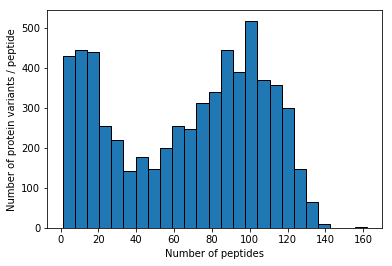

In [9]:
plt.hist(np.sum(~np.isnan(TEV_df),axis=1), bins=25, ec='k')
plt.xlabel("Number of peptides")
plt.ylabel("Number of protein variants / peptide")

Text(0,0.5,'Number of protein variants / peptide')

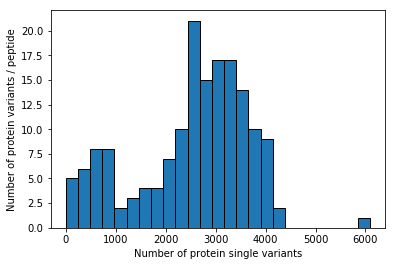

In [10]:
plt.hist(np.sum(~np.isnan(TEV_df),axis=0), bins=25, ec='k')
plt.xlabel("Number of protein single variants")
plt.ylabel("Number of protein variants / peptide")

In [11]:
tev_dataset = agg_df['mean_auc'].reset_index().set_index("TEVp").pivot(columns='TEVs', values='mean')

KeyError: 'mean'

In [ ]:
plt.hist(np.mean(~np.isnan(tev_dataset),axis=1), bins=30)

In [14]:
agg_df.loc[:,'mean_auc'].loc["wt"].sort_values("mean")

ValueError: No axis named mean for object type <type 'type'>

TEVp
A169C_T180E    0.0603
A169D          0.0580
A169D_D10V     0.0602
A169D_H142R    0.0590
A169E          0.0617
A169F          0.0564
A169H          0.0596
A169I          0.0593
A169K          0.0604
A169L          0.0633
A169M          0.0626
A169N          0.0590
A169P          0.0576
A169Q          0.0598
A169R          0.0482
A169S          0.0612
A169S_D10W     0.0655
A169S_D127C    0.0801
A169S_F162E    0.0703
A169S_G1Y      0.0702
A169S_I163A    0.0606
A169S_L155W    0.0586
A169T          0.0662
A169T_I163M    0.0601
A169W          0.0553
A169Y          0.0563
A195C          0.0962
A195D          0.0981
A195E          0.1060
A195E_L210C    0.0981
                ...  
Y178L          0.0590
Y178M          0.0646
Y178N          0.0576
Y178P          0.0552
Y178Q          0.0580
Y178R          0.0592
Y178S          0.0601
Y178T          0.0542
Y178V          0.0633
Y178W          0.0618
Y33A           0.0896
Y33C           0.0970
Y33D           0.0728
Y33E           0.0773
Y33F 

In [3]:
wt_seq = 'MGESLFKGPRDYNPISSSICHLTNESDGHTTSLWGIGFGPFIITNKHLFRRNNGTLVVQSLHGVFKVKDTTTLQQHLVDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSGDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMVKPEEPFQPVKEATQL'

In [4]:
def get_variant(reference, mutations, start_index=1):
    variant = reference.copy()
    for mut in mutations:
        pos = int(mut[1:-1])-start_index
        variant[pos] = mut[-1]
    return variant

In [13]:
variants = [get_variant(mutation.split('_') for mutation in raw_data_no_ins.index]

SyntaxError: invalid syntax (<ipython-input-13-adb09715044e>, line 1)

In [ ]:
raw_data_no_ins

In [10]:
raw_data_no_ins.pivot(columns='TEVs', values='AUC')

ValueError: Index contains duplicate entries, cannot reshape

In [12]:
all_TEVs = np.unique(raw_data_no_ins.TEVs)

In [10]:
for tevs in all_TEVs:

    raw_data_no_ins.loc[raw_data_no_ins.n_ all_TEVs]

,TEVs,n_mut_TEVp,n_mut_TEVs,source_TEVp,source_TEVs,N1,N2,N3,N4,N5,...,F4,F5,sum,min,t1,t2,t3,t4,t5,AUC
TEVp,,,,,,,,,,,,,,,,,,,,,
0_T29D,ENGYFQS,2,1,PacBio,PacBio,310,273,296,289,270,...,39,59,1548,275,0.0000,0.0073,0.0327,0.1189,0.1793,0.0621
0_T29D,ENIYFQS,2,1,PacBio,PacBio,43,46,30,21,25,...,6,15,189,27,0.0000,0.0213,0.0625,0.2222,0.3750,0.1234
0_T29D,ENLMFQS,2,1,PacBio,PacBio,56,82,62,76,62,...,9,14,362,56,0.0000,0.0120,0.0000,0.1059,0.1842,0.0525
0_T29D,ENLYFHS,2,1,PacBio,PacBio,42,29,27,32,37,...,10,4,181,27,0.0000,0.0000,0.0000,0.2381,0.0976,0.0717
0_T29D,ENLYFPS,2,1,PacBio,PacBio,81,72,66,81,71,...,3,14,393,70,0.0000,0.0137,0.0571,0.0357,0.1647,0.0472
0_T29D,ENLYFQF,2,1,PacBio,PacBio,96,102,105,120,124,...,0,1,551,96,0.0000,0.0097,0.0187,0.0000,0.0080,0.0081
0_T29D,ENLYFQM,2,1,PacBio,PacBio,324,328,287,319,285,...,44,73,1680,303,0.0000,0.0120,0.0528,0.1212,0.2039,0.0720
0_T29D,ENLYFQN,2,1,PacBio,PacBio,164,196,172,172,179,...,31,42,974,164,0.0000,0.0249,0.0703,0.1527,0.1900,0.0857
0_T29D,ENLYFQP,2,1,PacBio,PacBio,93,66,61,67,76,...,17,20,405,64,0.0000,0.0294,0.0469,0.2024,0.2083,0.0957


# Some light alignment analysis

/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: '../EVcouplings/ALPH_ELIME/alph_elime_b0.6/align/alph_elime_b0.6.a2m'